# Official HEC-HMS Guide Mirror: Advanced Analysis Types

Official guide: https://www.hec.usace.army.mil/confluence/hmsdocs/hmsguides/advanced-analysis-types-in-hms

This notebook inventories advanced-analysis artifacts and demonstrates the hms-commander building blocks for batch execution, ensemble spread, and objective-function convergence using actual HMS computations of Snyder unit hydrograph parameter variants.

In [1]:
from pathlib import Path
import logging

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

logging.disable(logging.CRITICAL)


def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "hms_commander").is_dir() and (candidate / "examples").is_dir():
            return candidate
    return start


REPO_ROOT = find_repo_root()
WORK_ROOT = REPO_ROOT / "examples" / "working" / "clb238_guides"
WORK_ROOT.mkdir(parents=True, exist_ok=True)
HMS_VERSION = "4.13"

from hms_commander import HmsExamples, HmsPrj

available_versions = HmsExamples.list_versions()
if HMS_VERSION not in available_versions:
    HMS_VERSION = available_versions[0]
HMS_EXE = HmsExamples.get_hms_exe(HMS_VERSION)


def init_sample_project(project_name, notebook_key, overwrite=True):
    project_path = HmsExamples.extract_project(
        project_name,
        version=HMS_VERSION,
        output_path=WORK_ROOT / notebook_key,
        overwrite=overwrite,
    )
    project = HmsPrj()
    project.initialize(project_path, hms_exe_path=HMS_EXE)
    return project, project_path

In [2]:
from hms_commander import HmsBasin, HmsCmdr, HmsDss, HmsJython

project, project_path = init_sample_project("castro", "106_advanced_analysis/baseline")
advanced_dirs = ["optimizer", "ensemble", "forecast", "frequency", "montecarlo"]
advanced_inventory = pd.DataFrame([
    {
        "artifact_family": dirname,
        "exists": (project_path / dirname).exists(),
        "file_count": len([path for path in (project_path / dirname).rglob("*") if path.is_file()]) if (project_path / dirname).exists() else 0,
    }
    for dirname in advanced_dirs
])

run_names = project.list_run_names()
batch_script = HmsJython.generate_batch_compute_script(project_path, run_names)
batch_script_checks = pd.DataFrame([
    {"check": f"contains run {run_name}", "passed": run_name in batch_script}
    for run_name in run_names
] + [
    {"check": "contains computation summary", "passed": "Computation Summary" in batch_script},
])
assert batch_script_checks["passed"].all()
display(advanced_inventory)
display(batch_script_checks)

,artifact_family,exists,file_count
0,optimizer,True,0
1,ensemble,True,0
2,forecast,True,0
3,frequency,True,0
4,montecarlo,True,0


,check,passed
0,contains run Current,True
1,contains run Future,True
2,contains computation summary,True


In [3]:
def read_outlet_pair(project_path, run_name="Current"):
    dss_file = project_path / "Current.dss"
    catalog = HmsDss.get_catalog(dss_file)
    modeled_path = next(path for path in catalog if "//OUTLET/FLOW/" in path.upper())
    observed_path = next(path for path in catalog if "//OUTLET/FLOW-OBSERVED/" in path.upper())
    modeled = HmsDss.read_timeseries(dss_file, modeled_path)[["value"]].rename(columns={"value": "modeled"})
    observed = HmsDss.read_timeseries(dss_file, observed_path)[["value"]].rename(columns={"value": "observed"})
    return modeled, observed

def compute_snyder_member(multiplier):
    member_key = f"tp_{multiplier:.2f}".replace(".", "p")
    member_project, member_path = init_sample_project(
        "castro",
        f"106_advanced_analysis/ensemble_{member_key}",
        overwrite=True,
    )
    run_name = "Current"
    config = member_project.get_run_configuration(run_name)
    basin_file = Path(config["basin_file"])
    transform = HmsBasin.get_all_transform_parameters(basin_file)
    transform["snyder_tp"] = transform["snyder_tp"].astype(float) * multiplier
    HmsBasin.set_all_transform_parameters(basin_file, transform[["name", "snyder_tp"]], create_backup=False)

    ok = HmsCmdr.compute_run(run_name, hms_object=member_project, timeout=120, save_project=False, max_memory="2G")
    assert ok
    modeled, observed = read_outlet_pair(member_path, run_name)
    series = modeled.rename(columns={"modeled": member_key})
    joined = observed.join(modeled, how="inner")
    residual = joined["modeled"] - joined["observed"]
    rmse = float(np.sqrt(np.mean(residual ** 2)))
    return series, observed, {
        "member": member_key,
        "snyder_tp_multiplier": multiplier,
        "peak_cfs": float(series[member_key].max()),
        "peak_time": series[member_key].idxmax(),
        "rmse_cfs": rmse,
    }

ensemble_members = [0.75, 0.90, 1.00, 1.10, 1.25]
member_series = []
metrics = []
observed_series = None
for multiplier in ensemble_members:
    series, observed, metric = compute_snyder_member(multiplier)
    member_series.append(series)
    metrics.append(metric)
    observed_series = observed if observed_series is None else observed_series

ensemble = pd.concat(member_series, axis=1).dropna()
observed_aligned = observed_series.reindex(ensemble.index).dropna()
metrics_df = pd.DataFrame(metrics)
metrics_df["evaluation"] = np.arange(1, len(metrics_df) + 1)
metrics_df["best_rmse_so_far"] = metrics_df["rmse_cfs"].cummin()
metrics_df

Configuring Java VM for DSS operations...
[OK] Java VM configured


,member,snyder_tp_multiplier,peak_cfs,peak_time,rmse_cfs,evaluation,best_rmse_so_far
0,tp_0p75,0.75,575.658541,1973-01-16 06:50:00,67.334859,1,67.334859
1,tp_0p90,0.90,558.204374,1973-01-16 06:55:00,64.549426,2,64.549426
2,tp_1p00,1.00,540.274905,1973-01-16 06:55:00,63.944624,3,63.944624
3,tp_1p10,1.10,522.106730,1973-01-16 06:55:00,65.506428,4,63.944624
4,tp_1p25,1.25,502.031721,1973-01-16 06:55:00,69.425585,5,63.944624


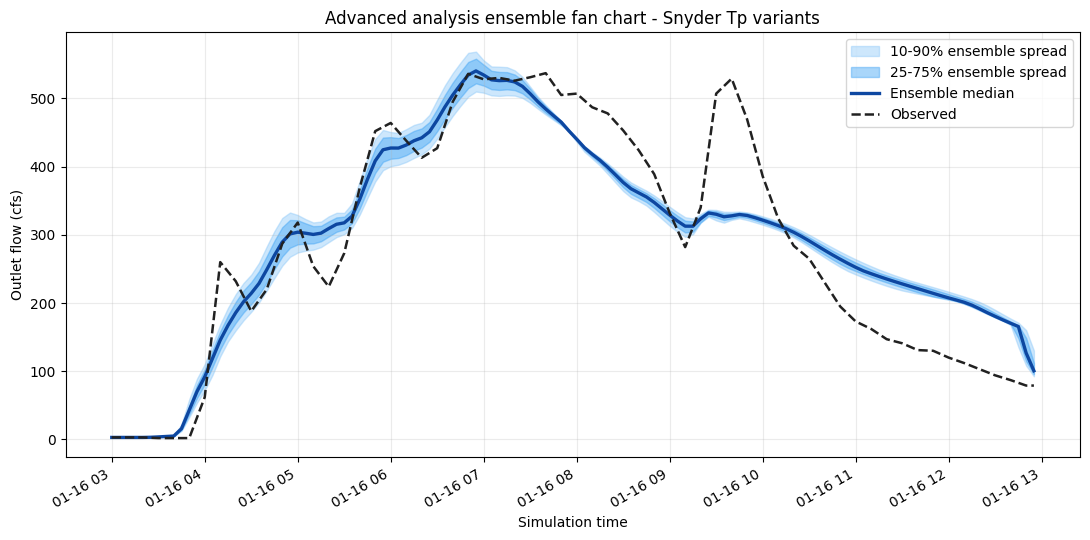

In [4]:
x = ensemble.index.to_pydatetime()
values = ensemble.to_numpy(dtype=float)
q10, q25, q50, q75, q90 = np.percentile(values, [10, 25, 50, 75, 90], axis=1)

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.fill_between(x, q10, q90, color="#90caf9", alpha=0.45, label="10-90% ensemble spread")
ax.fill_between(x, q25, q75, color="#42a5f5", alpha=0.45, label="25-75% ensemble spread")
ax.plot(x, q50, color="#0d47a1", linewidth=2.4, label="Ensemble median")
ax.plot(observed_aligned.index.to_pydatetime(), observed_aligned["observed"], color="#212121", linewidth=1.8, linestyle="--", label="Observed")
ax.set_title("Advanced analysis ensemble fan chart - Snyder Tp variants")
ax.set_xlabel("Simulation time")
ax.set_ylabel("Outlet flow (cfs)")
ax.grid(True, alpha=0.25)
ax.legend(loc="upper right")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

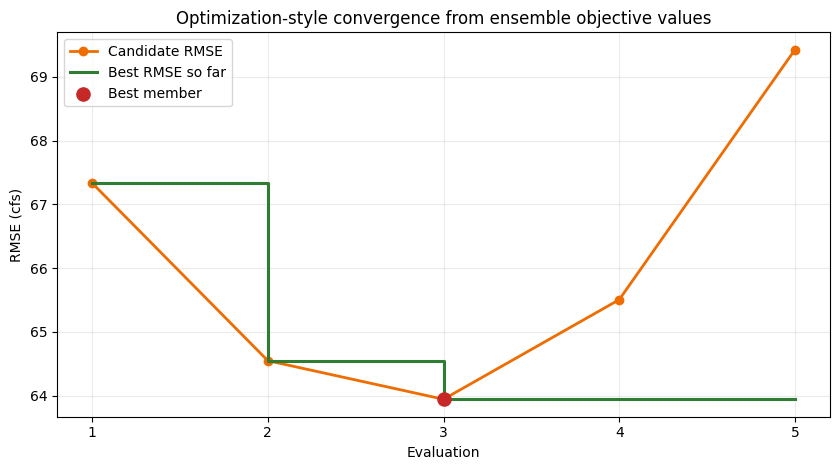

,member,snyder_tp_multiplier,peak_cfs,peak_time,rmse_cfs,evaluation,best_rmse_so_far
0,tp_0p75,0.75,575.7,1973-01-16 06:50:00,67.33,1,67.334859
1,tp_0p90,0.90,558.2,1973-01-16 06:55:00,64.55,2,64.549426
2,tp_1p00,1.00,540.3,1973-01-16 06:55:00,63.94,3,63.944624
3,tp_1p10,1.10,522.1,1973-01-16 06:55:00,65.51,4,63.944624
4,tp_1p25,1.25,502.0,1973-01-16 06:55:00,69.43,5,63.944624


In [5]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.plot(metrics_df["evaluation"], metrics_df["rmse_cfs"], marker="o", linewidth=2, color="#ef6c00", label="Candidate RMSE")
ax.step(metrics_df["evaluation"], metrics_df["best_rmse_so_far"], where="post", linewidth=2.2, color="#2e7d32", label="Best RMSE so far")
best = metrics_df.loc[metrics_df["rmse_cfs"].idxmin()]
ax.scatter([best["evaluation"]], [best["rmse_cfs"]], s=90, color="#c62828", zorder=3, label="Best member")
ax.set_title("Optimization-style convergence from ensemble objective values")
ax.set_xlabel("Evaluation")
ax.set_ylabel("RMSE (cfs)")
ax.set_xticks(metrics_df["evaluation"])
ax.grid(True, alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

metrics_df.assign(
    peak_cfs=metrics_df["peak_cfs"].round(1),
    rmse_cfs=metrics_df["rmse_cfs"].round(2),
)

## Coverage Notes

Native HMS optimization, uncertainty-analysis, ensemble-analysis, save-state, and stochastic-storm-transposition objects still need first-class hms-commander APIs. This notebook demonstrates the current executable bridge: generate batch scripts, create parameter variants, compute the variants, plot hydrograph spread, and evaluate objective values.